Matriz topográfica lista Dimensiones: (557, 743)
Elevación mínima: 136.0m, Máxima: 178.2m
Pendiente máxima detectada en el terreno: 0.470


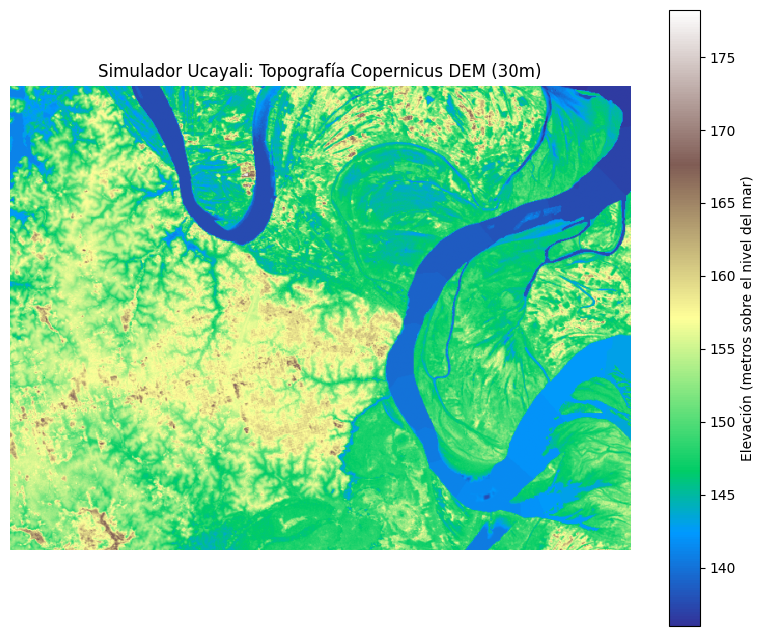

In [2]:
import ee
import requests
import rasterio
from rasterio.io import MemoryFile
import numpy as np
import matplotlib.pyplot as plt

# --- OPTIMIZACIÓN 1: Autenticación inteligente ---
# Intenta inicializar directo. Solo pide autenticación si Colab olvidó la sesión temporal.
try:
    ee.Initialize(project='wildfire-sim-2026')
except Exception:
    ee.Authenticate()
    ee.Initialize(project='wildfire-sim-2026')

# 1. Definir tu área de Pucallpa
pucallpa = ee.Geometry.Rectangle([-74.65, -8.45, -74.45, -8.30])

# --- OPTIMIZACIÓN 2: Encadenamiento de métodos ---
# Llamamos a Copernicus, lo hacemos mosaico y lo recortamos en una sola operación
dem_recortado = (ee.ImageCollection('COPERNICUS/DEM/GLO30_2024_1')
                 .select('DEM')
                 .mosaic()
                 .clip(pucallpa))

# 2. Solicitar a Google el empaquetado del mapa a 30 metros
url_dem = dem_recortado.getDownloadURL({
    'scale': 30,
    'crs': 'EPSG:4326',
    'region': pucallpa,
    'format': 'GEO_TIFF'
})

# 3. Descargar y decodificar directamente en la RAM
respuesta_dem = requests.get(url_dem)
with MemoryFile(respuesta_dem.content) as memfile:
    with memfile.open() as dataset:
        matriz_elevacion = dataset.read(1)

#  Asegurarnos de que no queden valores infinitos o nulos extraños
matriz_elevacion = np.nan_to_num(matriz_elevacion, nan=np.nanmean(matriz_elevacion))
# --- OPTIMIZACIÓN 3: Cálculo automático de la pendiente ---
# Le decimos a NumPy que calcule la inclinación sabiendo que cada píxel mide 30 metros.
# Esto devuelve dos matrices (inclinación Norte-Sur e inclinación Este-Oeste)
gradiente_y, gradiente_x = np.gradient(matriz_elevacion, 30)

# Validar la estructura matemática (redondeando los decimales para que se vea más limpio)
print(f"Matriz topográfica lista Dimensiones: {matriz_elevacion.shape}")
print(f"Elevación mínima: {np.min(matriz_elevacion):.1f}m, Máxima: {np.max(matriz_elevacion):.1f}m")
print(f"Pendiente máxima detectada en el terreno: {np.max(np.abs(gradiente_x)):.3f}")

# 4. Visualización para el equipo
plt.figure(figsize=(10, 8))
mapa_relieve = plt.imshow(matriz_elevacion, cmap='terrain')
plt.colorbar(mapa_relieve, label='Elevación (metros sobre el nivel del mar)')
plt.title('Simulador Ucayali: Topografía Copernicus DEM (30m)')
plt.axis('off')
plt.show()